Farhan Dwifaza Rosyadi (23051130062)

Farhan Dwifaza Rosyadi (23051130062)

Farhan Dwifaza Rosyadi (23051130062)


# Telco Customer Churn

## Business Problem Understanding

**Context**

Sebuah perusahaan telekomunikasi menghadapi tingginya tingkat pelanggan berhenti berlangganan (churn). Pelanggan yang berhenti menyebabkan hilangnya pendapatan berulang dan meningkatkan biaya akuisisi pelanggan baru. Perusahaan ingin memprediksi lebih awal apakah seorang pelanggan berpotensi churn berdasarkan karakteristik layanan dan perilaku penggunaan.

Target :

No  = Tidak churn (tetap berlangganan)

Yes = Churn (berhenti berlangganan)

**Problem Statement :**

Tingkat churn pelanggan menimbulkan kerugian bagi perusahaan karena berkurangnya pendapatan berulang dan meningkatnya biaya akuisisi. Tanpa identifikasi risiko churn, perusahaan memperlakukan seluruh pelanggan secara sama sehingga program retensi tidak tepat sasaran.

Ketidakpastian ini membuat perusahaan sulit merancang strategi retensi yang efektif. Dibutuhkan pendekatan prediktif untuk mengenali pelanggan berisiko tinggi agar intervensi dapat dilakukan lebih dini dan lebih efisien.

**Goals :**

Berdasarkan permasalahan di atas, proyek ini bertujuan membangun model klasifikasi untuk memprediksi churn pelanggan. Solusi dianggap berhasil apabila model mampu memberikan prediksi yang akurat dan dapat memberi insight mengenai faktor yang memengaruhi churn.

**Analytic Approach :**

Pendekatan analitik menggunakan model klasifikasi dengan tahapan pembersihan data, analisis eksploratif, feature engineering, encoding variabel kategorikal, serta evaluasi model. Fokus evaluasi utama adalah Recall dan ROC AUC agar model efektif mendeteksi pelanggan yang berisiko churn.

**Model**

Logistic Regression

KNN

Decision Tree

Random Forest

XGBoost

LightGBM

## Data Understanding

Dataset source : data_telco_customer_churn.csv (local file)

Notes:
-  Dataset berisi informasi layanan dan tagihan pelanggan telekomunikasi.
-  Target `Churn` bersifat biner (Yes/No).
-  Sebagian besar fitur bersifat kategorikal.
-  Setiap baris merepresentasikan satu pelanggan.

### Attribute Information - Telco Customer Churn
| Attribute          | Data Type | Description |
| ------------------ | --------- | ----------- |
| Dependents         | Text      | Apakah pelanggan memiliki tanggungan |
| tenure             | Integer   | Lama pelanggan berlangganan (bulan) |
| OnlineSecurity     | Text      | Status layanan keamanan online |
| OnlineBackup       | Text      | Status layanan backup online |
| InternetService    | Text      | Tipe layanan internet |
| DeviceProtection   | Text      | Status perlindungan perangkat |
| TechSupport        | Text      | Status dukungan teknis |
| Contract           | Text      | Jenis kontrak pelanggan |
| PaperlessBilling   | Text      | Tagihan tanpa kertas |
| MonthlyCharges     | Float     | Biaya bulanan pelanggan |
| Churn              | Text      | **Target**: Yes = churn, No = tidak churn |


In [19]:
!pip install category_encoders
!pip install xgboost
!pip install imbalanced-learn
# Library
import pandas as pd
import numpy as np
import category_encoders as ce

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from IPython.display import display
plt.style.use("seaborn-v0_8-whitegrid")

# Feature Engineering
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder, StandardScaler)
from sklearn.compose import ColumnTransformer

# Model Selection n Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

# Imbalance Dataset Handling
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

# Saving Model
import joblib
import pickle

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Set max columns
pd.set_option('display.max_columns', None)

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]




[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
# Load dataset (local)
df = pd.read_csv("data_telco_customer_churn.csv")
df.head()

,Dependents,tenure,OnlineSecurity,OnlineBackup,InternetService,DeviceProtection,TechSupport,Contract,PaperlessBilling,MonthlyCharges,Churn
0,Yes,9,No,No,DSL,Yes,Yes,Month-to-month,Yes,72.90,Yes
1,No,14,No,Yes,Fiber optic,Yes,No,Month-to-month,Yes,82.65,No
2,No,64,Yes,No,DSL,Yes,Yes,Two year,No,47.85,Yes
3,No,72,Yes,Yes,DSL,Yes,Yes,Two year,No,69.65,No
4,No,3,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,Yes,23.60,No


Dataset dimuat dari file lokal `data_telco_customer_churn.csv` agar mudah dijalankan oleh semua anggota tim tanpa bergantung pada link eksternal.

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4930 entries, 0 to 4929
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Dependents        4930 non-null   object 
 1   tenure            4930 non-null   int64  
 2   OnlineSecurity    4930 non-null   object 
 3   OnlineBackup      4930 non-null   object 
 4   InternetService   4930 non-null   object 
 5   DeviceProtection  4930 non-null   object 
 6   TechSupport       4930 non-null   object 
 7   Contract          4930 non-null   object 
 8   PaperlessBilling  4930 non-null   object 
 9   MonthlyCharges    4930 non-null   float64
 10  Churn             4930 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 423.8+ KB


## Data Cleaning

In [66]:
listItem = []
for col in df.columns:
    non_null = df[col].dropna()
    unique_vals = non_null.unique()
    sample_size = 2 if len(unique_vals) >= 2 else len(unique_vals)
    sample_vals = (
        list(pd.Series(unique_vals).sample(sample_size, random_state=42).values)
        if sample_size > 0
        else []
    )
    listItem.append([
        col,
        df[col].dtype,
        df[col].isna().sum(),
        round((df[col].isna().sum() / len(df[col])) * 100, 2),
        df[col].nunique(),
        sample_vals
    ])
dfDesc = pd.DataFrame(
    columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
    data=listItem,
 )
dfDesc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,Dependents,object,0,0.0,2,"[No, Yes]"
1,tenure,int64,0,0.0,73,"[3, 27]"
2,OnlineSecurity,object,0,0.0,3,"[No, Yes]"
3,OnlineBackup,object,0,0.0,3,"[No, Yes]"
4,InternetService,object,0,0.0,3,"[DSL, Fiber optic]"
5,DeviceProtection,object,0,0.0,3,"[Yes, No internet service]"
6,TechSupport,object,0,0.0,3,"[Yes, No]"
7,Contract,object,0,0.0,3,"[Month-to-month, Two year]"
8,PaperlessBilling,object,0,0.0,2,"[No, Yes]"
9,MonthlyCharges,float64,0,0.0,1422,"[26.35, 68.4]"


Tabel ini merangkum tipe data, jumlah nilai kosong, persentase missing value, serta jumlah nilai unik pada setiap kolom. Informasi ini membantu menentukan langkah data cleaning yang diperlukan.

<Axes: >

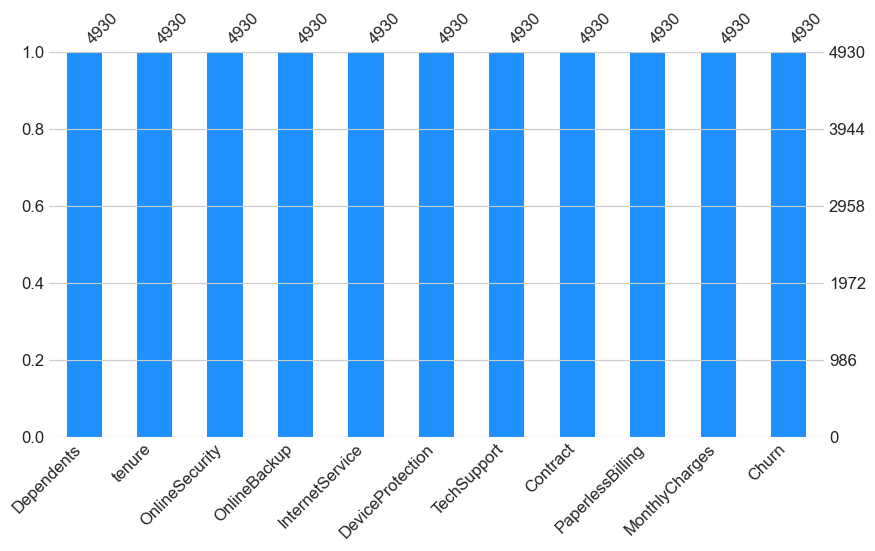

In [67]:
# Missing value - bar plot
msno.bar(df, color="dodgerblue", sort="ascending", figsize=(10, 5), fontsize=12)

Bar plot memperlihatkan jumlah data yang tersedia pada setiap kolom, sehingga memudahkan identifikasi kolom yang memiliki missing values.

<Axes: >

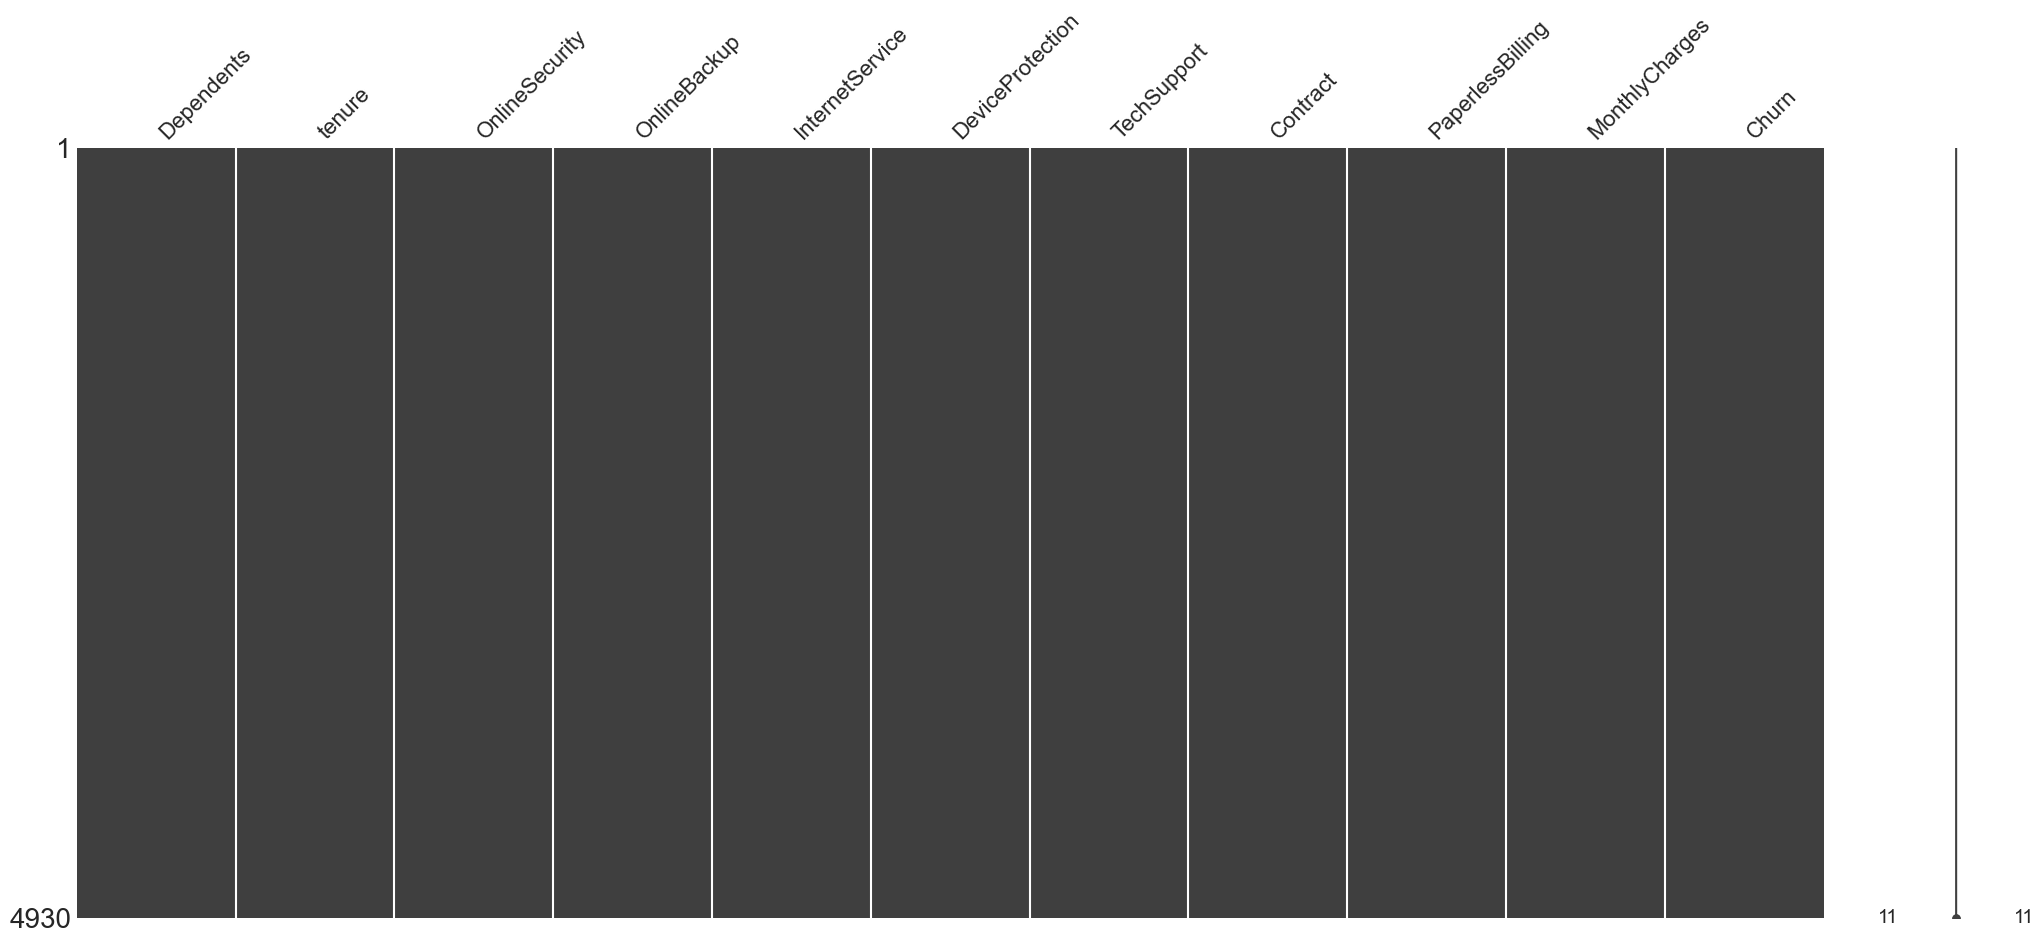

In [68]:
# Missing value - matrix
msno.matrix(df)

Matrix ini menampilkan pola missing value pada setiap baris data untuk melihat apakah ada pola khusus pada data yang hilang.

<Axes: >

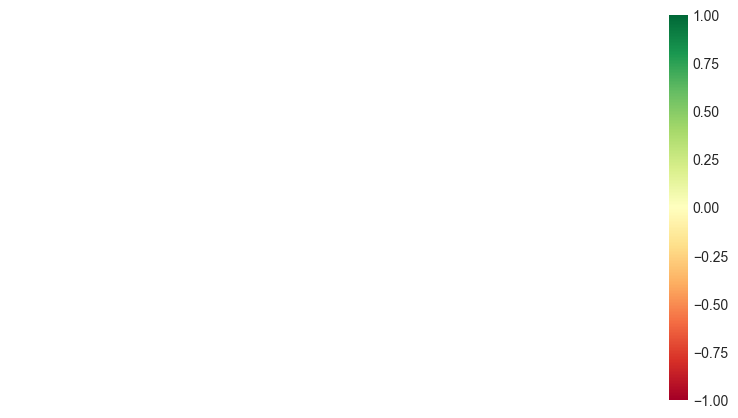

In [69]:
# Missing value - heatmap
msno.heatmap(df, cmap="RdYlGn", figsize=(10, 5), fontsize=12)

Heatmap ini membantu melihat korelasi missing value antar kolom. Jika tidak terlihat pola khusus, missing value cenderung acak.

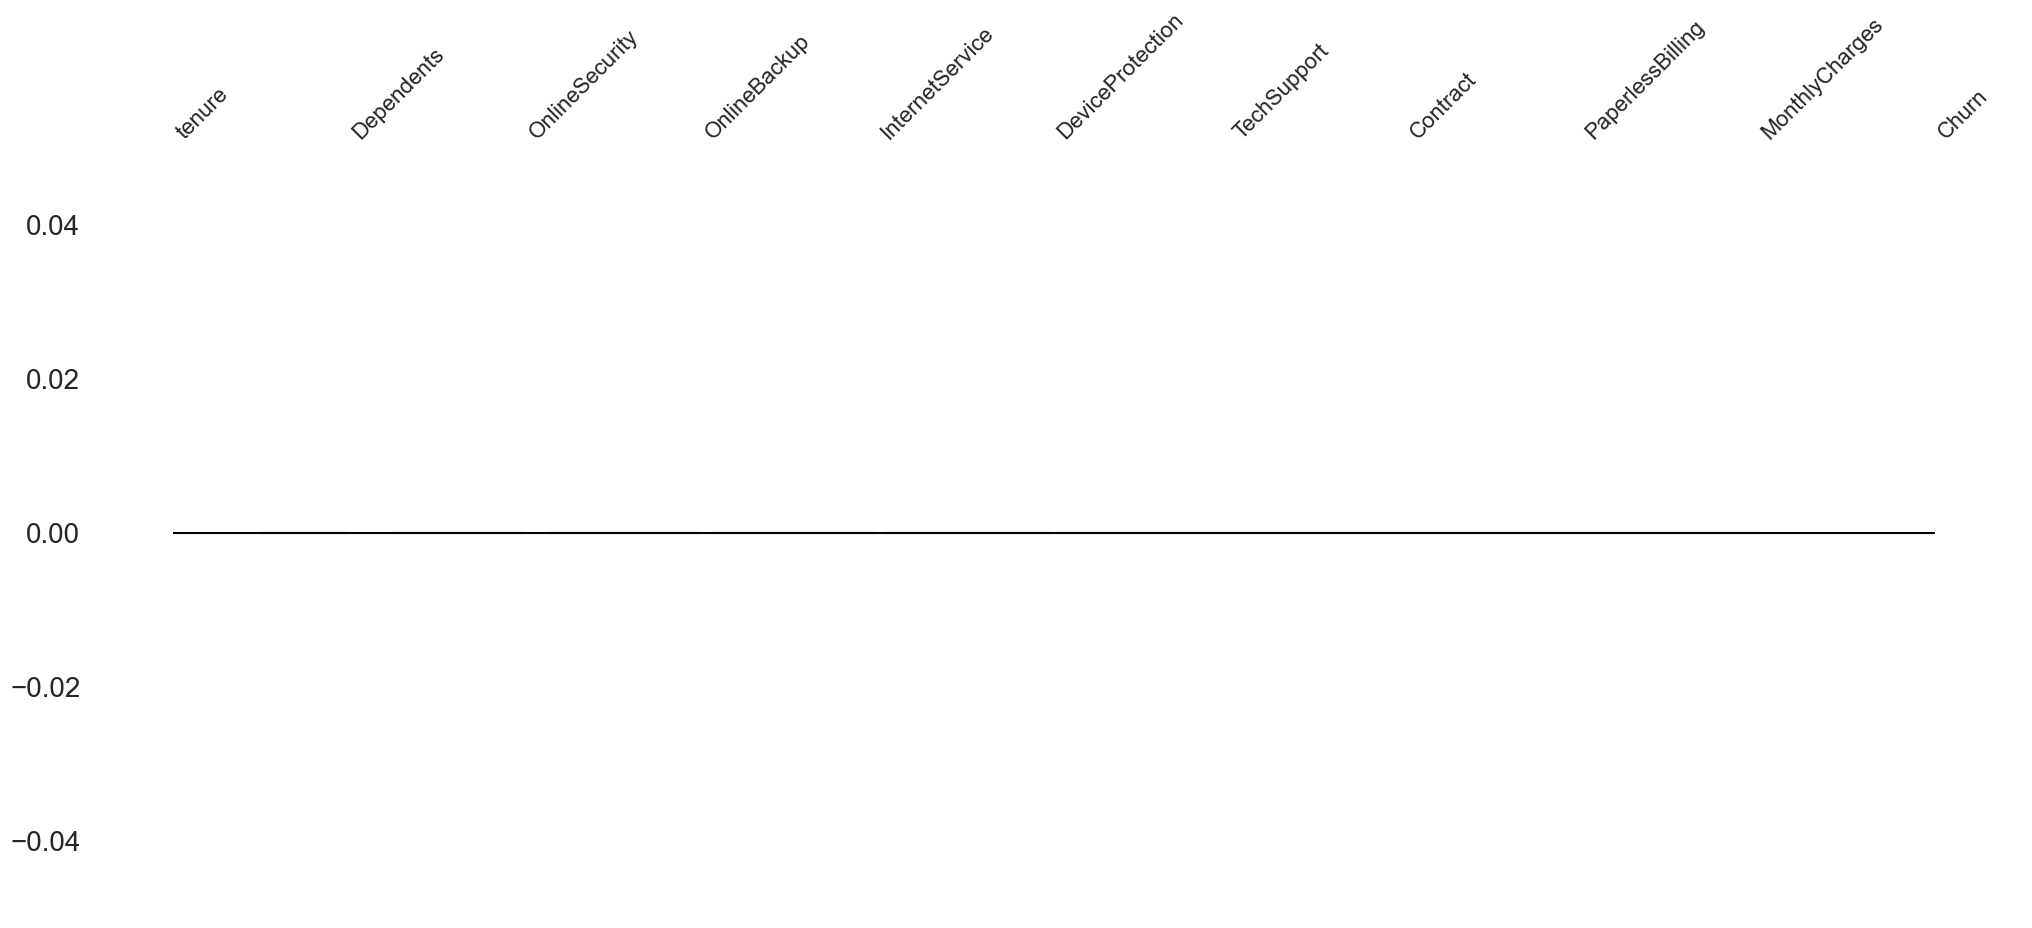

In [70]:
# Missing value - dendrogram
msno.dendrogram(df)
plt.show()

Dendrogram menggambarkan kedekatan pola missing value antar kolom. Ini berguna untuk memahami apakah ada kolom yang sering kosong secara bersamaan.

Setelah pengecekan missing value, tahap berikutnya adalah memeriksa duplikasi data untuk memastikan tidak ada baris yang sama berulang kali.

In [71]:
# Cek duplicated data
dup_count = df.duplicated().sum()
print("Jumlah baris duplikat:", dup_count)

Jumlah baris duplikat: 77


Jika jumlah duplikasi lebih dari 0, data perlu dibersihkan agar tidak mengganggu proses pemodelan.

Selanjutnya dilakukan pengecekan tipe data dan standardisasi kolom penting seperti `tenure`, `MonthlyCharges`, dan target `Churn`.

In [72]:
# Standarisasi tipe data dan target
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['Churn'] = df['Churn'].astype(str).str.strip().map({'Yes': 1, 'No': 0})

print(df.dtypes)

Dependents           object
tenure                int64
OnlineSecurity       object
OnlineBackup         object
InternetService      object
DeviceProtection     object
TechSupport          object
Contract             object
PaperlessBilling     object
MonthlyCharges      float64
Churn                 int64
dtype: object


Kolom numerik dipastikan bertipe angka, sedangkan target `Churn` dikonversi menjadi biner (Yes=1, No=0) agar kompatibel dengan evaluasi ROC AUC dan Recall.

In [73]:
# Penanganan missing values (jika ada)
missing_total = df.isna().sum().sum()
print("Total missing values:", missing_total)

if missing_total > 0:
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Churn', errors='ignore')
    cat_cols = df.select_dtypes(include=['object']).columns

    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])
    print("Missing values telah ditangani.")
else:
    print("Tidak ada missing values yang perlu ditangani.")

Total missing values: 0
Tidak ada missing values yang perlu ditangani.


Jika terdapat nilai kosong, dilakukan imputasi sederhana: median untuk numerik dan modus untuk kategorikal. Jika tidak ada missing values, data tetap dibiarkan apa adanya.

In [74]:
# Hapus duplikasi jika ada
if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplikasi dihapus. Jumlah data sekarang:", len(df))
else:
    print("Tidak ada duplikasi yang perlu dihapus.")

Duplikasi dihapus. Jumlah data sekarang: 4853


Jika ditemukan duplikasi, baris yang sama dihapus agar tidak memperbesar bias pada proses training.

In [75]:
# Update ringkasan setelah cleaning
listItem = []
for col in df.columns:
    non_null = df[col].dropna()
    unique_vals = non_null.unique()
    sample_size = 2 if len(unique_vals) >= 2 else len(unique_vals)
    sample_vals = (
        list(pd.Series(unique_vals).sample(sample_size, random_state=42).values)
        if sample_size > 0
        else []
    )
    listItem.append([
        col,
        df[col].dtype,
        df[col].isna().sum(),
        round((df[col].isna().sum() / len(df[col])) * 100, 2),
        df[col].nunique(),
        sample_vals
    ])
dfDesc = pd.DataFrame(
    columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
    data=listItem,
 )
dfDesc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,Dependents,object,0,0.0,2,"[No, Yes]"
1,tenure,int64,0,0.0,73,"[3, 27]"
2,OnlineSecurity,object,0,0.0,3,"[No, Yes]"
3,OnlineBackup,object,0,0.0,3,"[No, Yes]"
4,InternetService,object,0,0.0,3,"[DSL, Fiber optic]"
5,DeviceProtection,object,0,0.0,3,"[Yes, No internet service]"
6,TechSupport,object,0,0.0,3,"[Yes, No]"
7,Contract,object,0,0.0,3,"[Month-to-month, Two year]"
8,PaperlessBilling,object,0,0.0,2,"[No, Yes]"
9,MonthlyCharges,float64,0,0.0,1422,"[26.35, 68.4]"


Ringkasan ini memastikan data sudah bersih dari missing values, duplikasi, dan tipe data yang tidak sesuai sebelum masuk ke tahap analisis.

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4853 entries, 0 to 4852
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Dependents        4853 non-null   object 
 1   tenure            4853 non-null   int64  
 2   OnlineSecurity    4853 non-null   object 
 3   OnlineBackup      4853 non-null   object 
 4   InternetService   4853 non-null   object 
 5   DeviceProtection  4853 non-null   object 
 6   TechSupport       4853 non-null   object 
 7   Contract          4853 non-null   object 
 8   PaperlessBilling  4853 non-null   object 
 9   MonthlyCharges    4853 non-null   float64
 10  Churn             4853 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 417.2+ KB


Struktur data menunjukkan jumlah baris, kolom, serta tipe data akhir setelah cleaning. Ini memastikan dataset siap digunakan untuk analisis lebih lanjut.

## Data Analysis

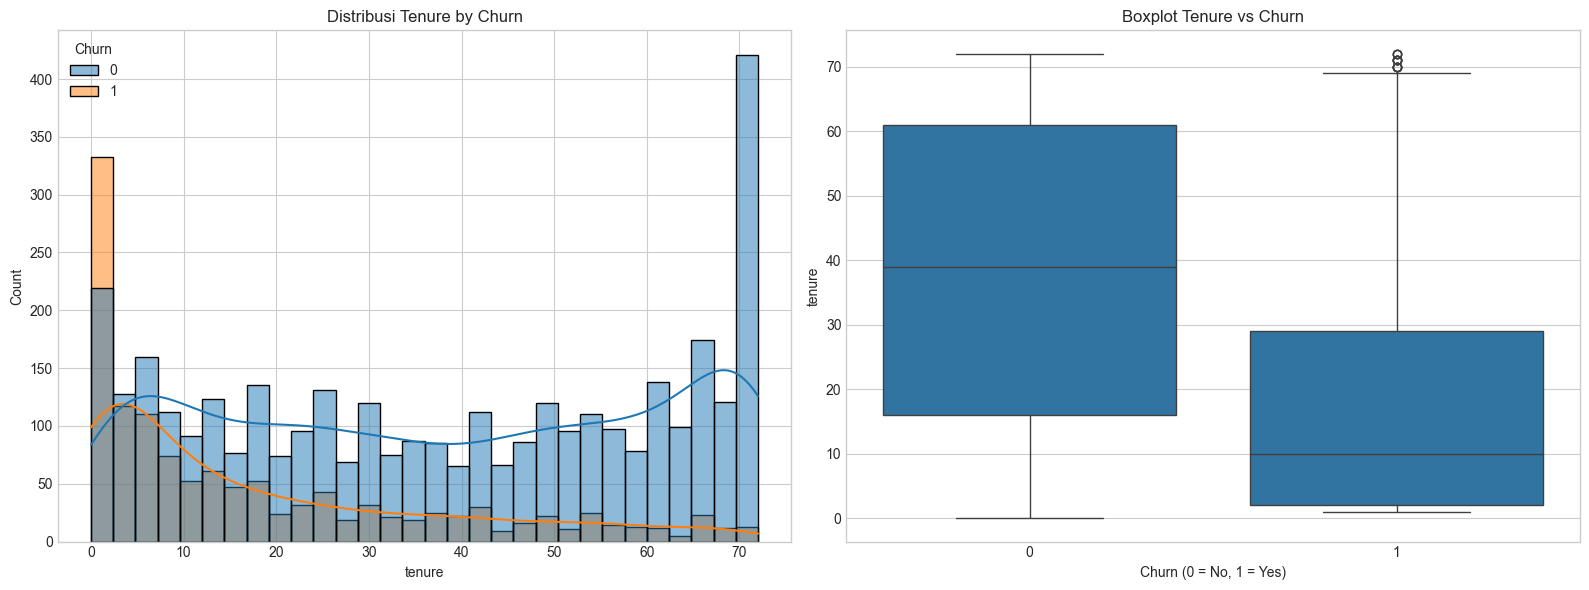

In [77]:
# Distribusi tenure dan churn
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[0], bins=30)
axes[0].set_title('Distribusi Tenure by Churn')

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1])
axes[1].set_title('Boxplot Tenure vs Churn')
axes[1].set_xlabel('Churn (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()

Visualisasi ini memperlihatkan distribusi lama berlangganan (tenure) terhadap churn. Pola ini membantu melihat apakah pelanggan baru cenderung lebih sering churn dibanding pelanggan lama.

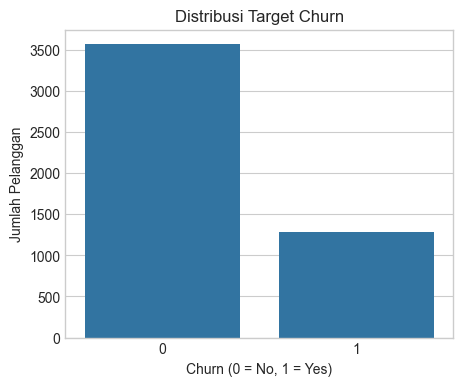

In [78]:
# Distribusi target
plt.figure(figsize=(5, 4))
sns.countplot(x='Churn', data=df)
plt.title('Distribusi Target Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Jumlah Pelanggan')
plt.show()

Grafik ini menampilkan distribusi kelas target `Churn`. Perbedaan jumlah antar kelas menunjukkan potensi imbalance yang perlu diperhatikan saat pemodelan.

In [79]:
print("Proporsi kelas target (%):")
print(df['Churn'].value_counts(normalize=True) * 100)

Proporsi kelas target (%):
Churn
0    73.459716
1    26.540284
Name: proportion, dtype: float64


Proporsi kelas target menunjukkan keseimbangan churn vs non-churn pada dataset. Informasi ini penting untuk menentukan strategi evaluasi dan penanganan imbalance.

In [80]:
# Perbandingan churn berdasarkan biaya bulanan (median split)
median_charge = df['MonthlyCharges'].median()
high_charge = df[df['MonthlyCharges'] > median_charge]['Churn'].mean() * 100
low_charge = df[df['MonthlyCharges'] <= median_charge]['Churn'].mean() * 100

print(f"Persentase Churn jika MonthlyCharges > Median : {high_charge:.2f}%")
print(f"Persentase Churn jika MonthlyCharges <= Median: {low_charge:.2f}%")

Persentase Churn jika MonthlyCharges > Median : 35.41%
Persentase Churn jika MonthlyCharges <= Median: 17.68%


Perbandingan ini membantu melihat apakah pelanggan dengan biaya bulanan lebih tinggi cenderung memiliki risiko churn yang berbeda dibanding pelanggan dengan biaya lebih rendah.

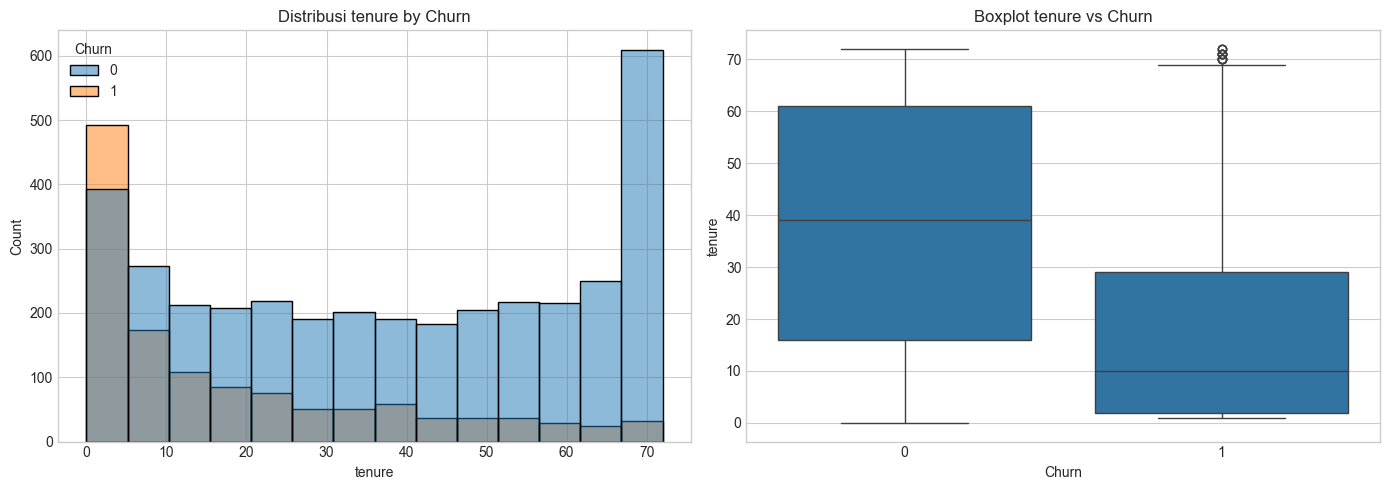

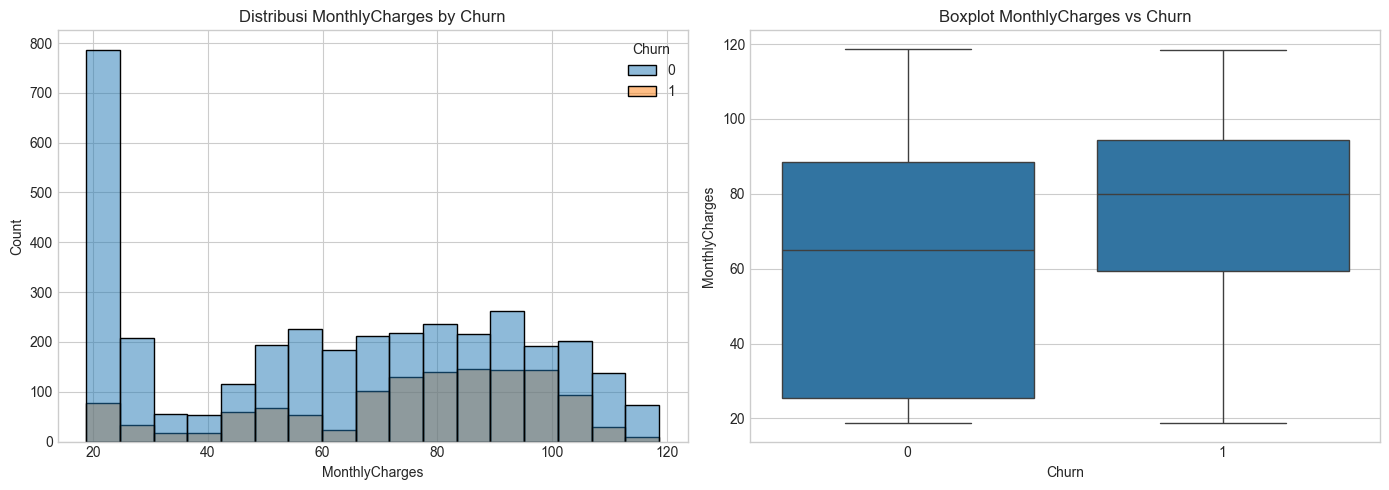

In [81]:
# Distribusi fitur numerik utama
num_cols = ['tenure', 'MonthlyCharges']

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(data=df, x=col, hue='Churn', kde=False, ax=axes[0])
    axes[0].set_title(f'Distribusi {col} by Churn')

    sns.boxplot(data=df, x='Churn', y=col, ax=axes[1])
    axes[1].set_title(f'Boxplot {col} vs Churn')

    plt.tight_layout()
    plt.show()

Histogram dan boxplot menampilkan sebaran `tenure` dan `MonthlyCharges` terhadap status churn. Pola ini membantu mengidentifikasi perbedaan karakteristik pelanggan churn vs non-churn.

In [82]:
# Crosstab fitur kategorikal dan churn
cols_to_analyze = [
    'Contract',
    'InternetService',
    'OnlineSecurity',
    'TechSupport',
    'PaperlessBilling'
 ]

Fitur-fitur kategorikal ini dianalisis menggunakan crosstab untuk melihat perbedaan proporsi churn pada setiap kategori layanan.

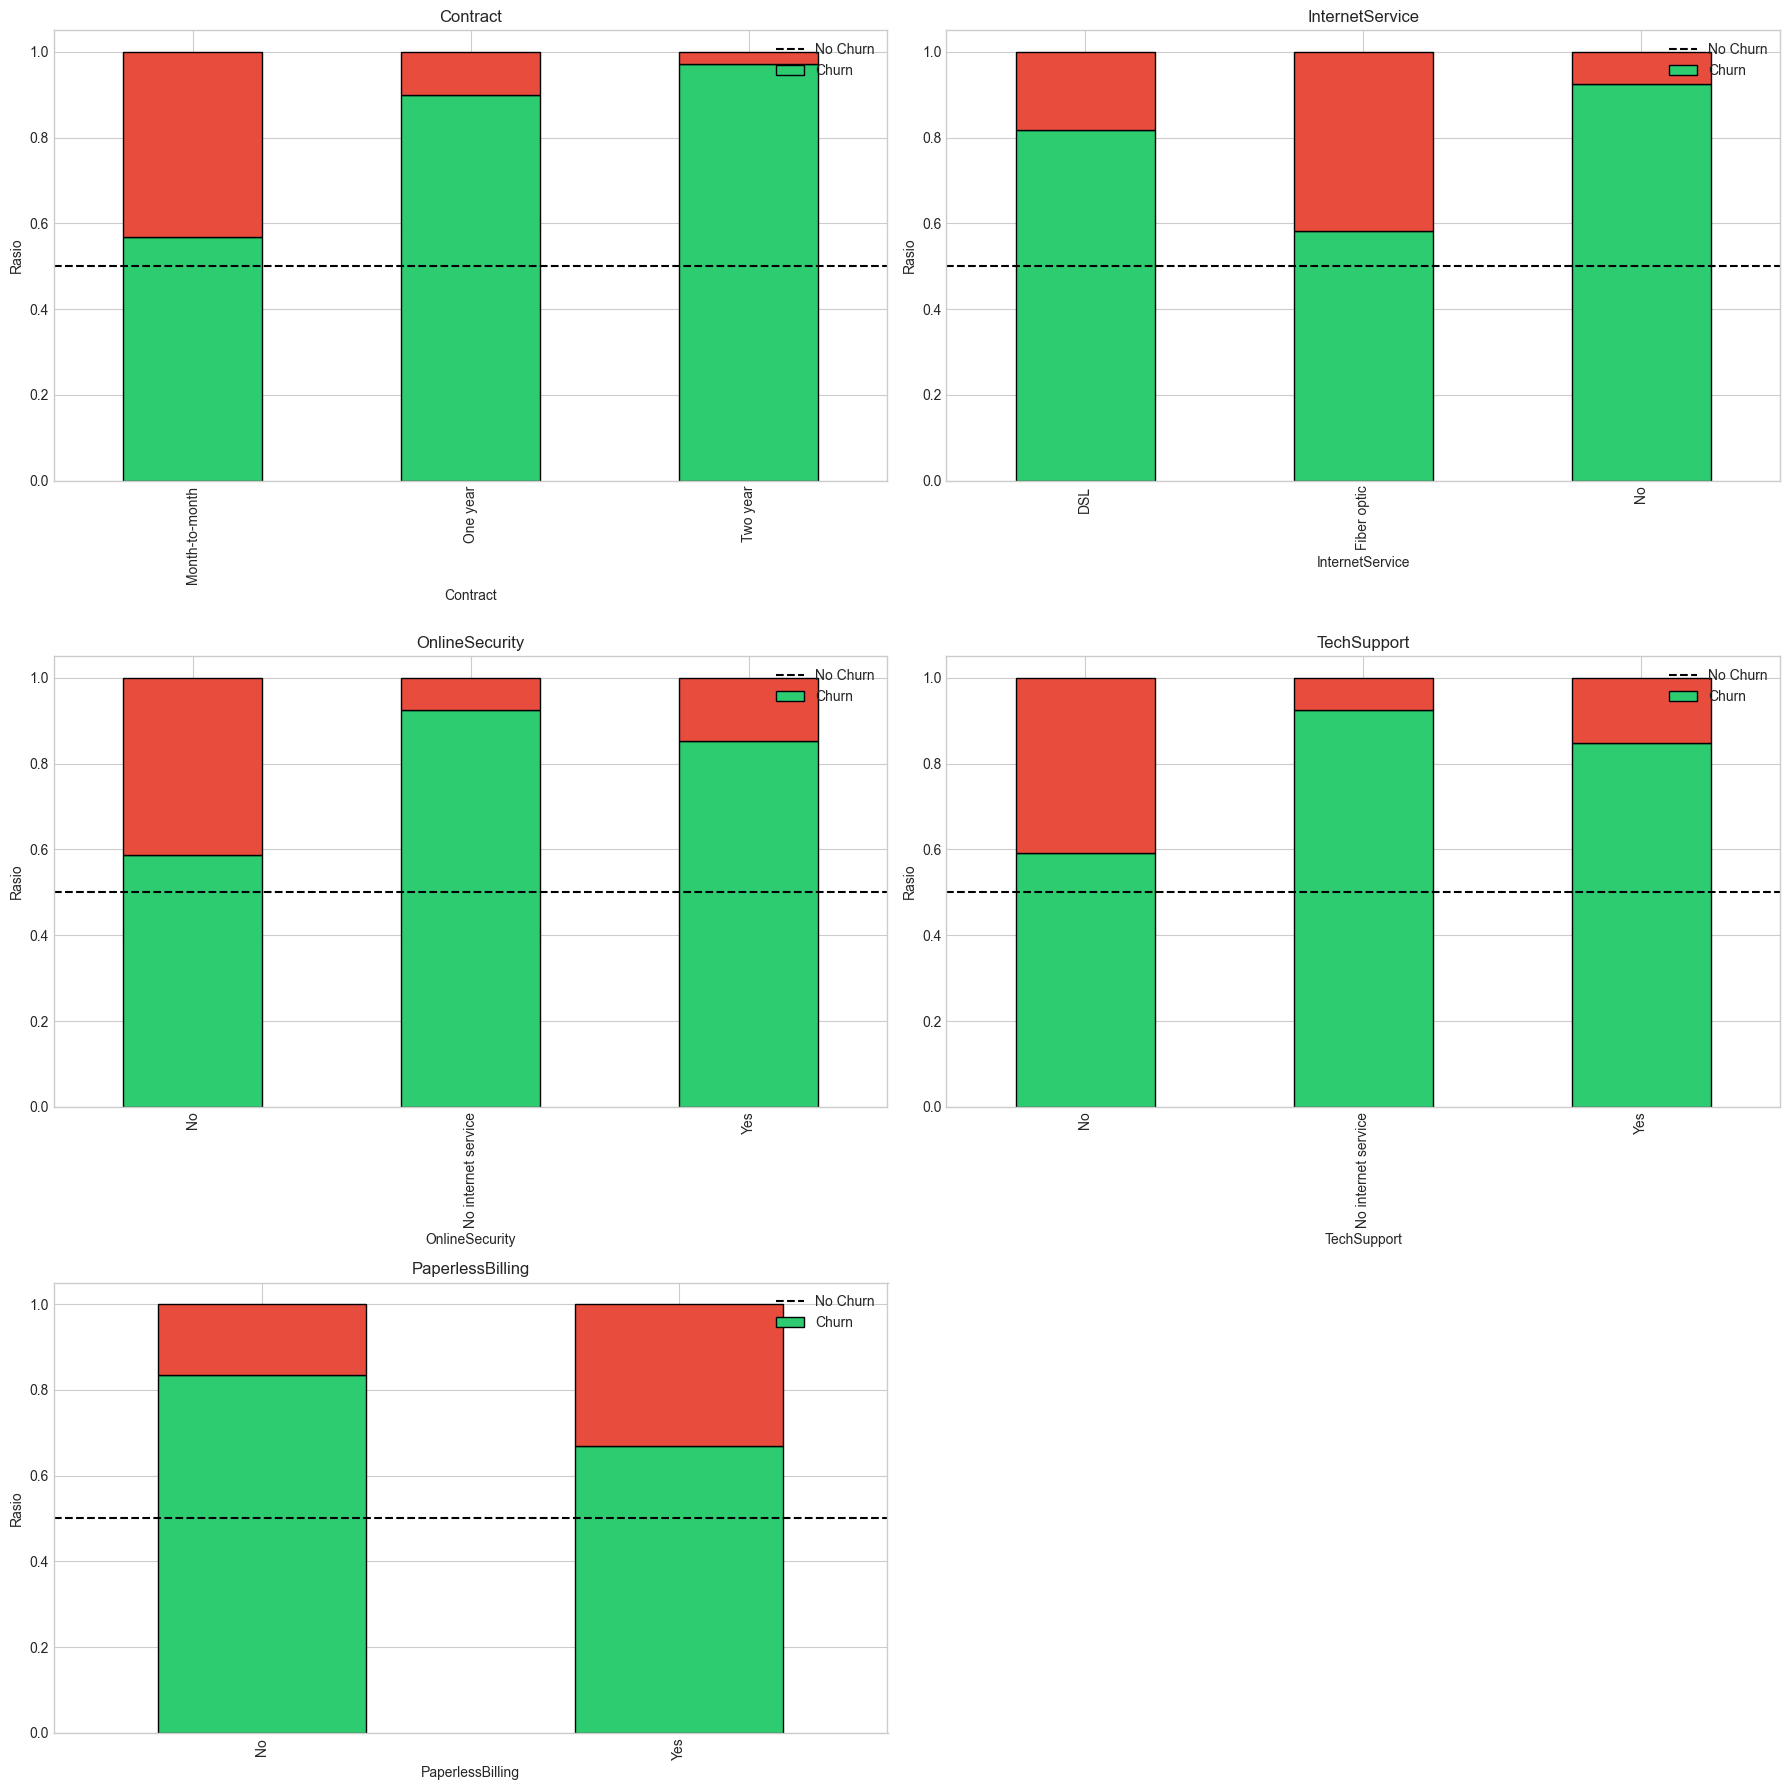

In [83]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(cols_to_analyze):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'], edgecolor='black')

    axes[i].set_title(col)
    axes[i].set_ylabel('Rasio')
    axes[i].axhline(0.5, color='black', linestyle='--')
    axes[i].legend(['No Churn', 'Churn'], loc='upper right')

for j in range(len(cols_to_analyze), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Grafik stacked bar memperlihatkan proporsi churn di setiap kategori layanan. Garis 0.5 membantu melihat apakah suatu kategori cenderung lebih tinggi churn atau tidak.

In [84]:
# Analisis churn berdasarkan Contract
contract_analysis = df.groupby('Contract')['Churn'].agg(['count', 'mean'])
contract_analysis.columns = ['Total Customers', 'Churn Rate']
contract_analysis['Churn Rate'] = contract_analysis['Churn Rate'] * 100

print("Analisis Churn Berdasarkan Contract")
display(contract_analysis.sort_values(by='Total Customers', ascending=False))

Analisis Churn Berdasarkan Contract


,Total Customers,Churn Rate
Contract,,
Month-to-month,2665,43.151970
Two year,1143,2.799650
One year,1045,10.143541


Tabel ini menunjukkan jumlah pelanggan dan persentase churn pada masing-masing jenis kontrak. Informasi ini membantu melihat kontrak mana yang lebih berisiko churn.

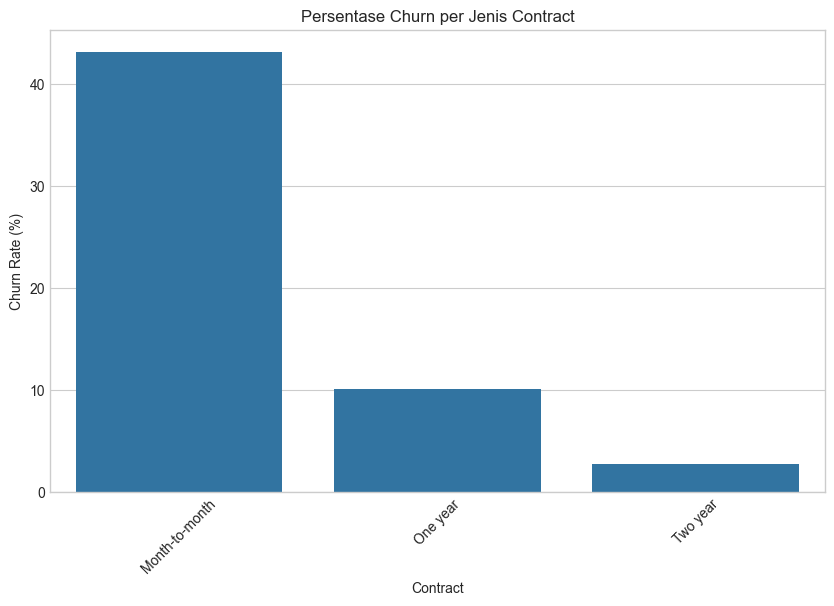

In [85]:
plt.figure(figsize=(10, 6))
sns.barplot(data=contract_analysis.reset_index(), x='Contract', y='Churn Rate')
plt.xticks(rotation=45)
plt.title('Persentase Churn per Jenis Contract')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Contract')
plt.show()

Grafik ini memperlihatkan perbandingan persentase churn untuk setiap jenis kontrak, sehingga mudah mengidentifikasi kontrak dengan risiko churn lebih tinggi.

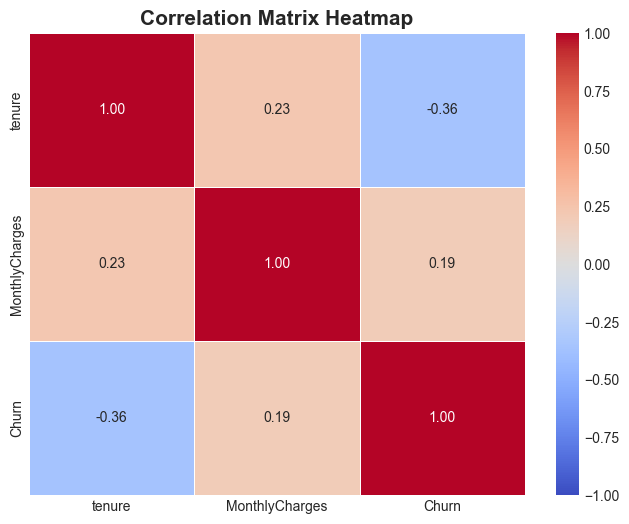

In [86]:
# Correlation heatmap variabel numerik
df_numeric = df[['tenure', 'MonthlyCharges', 'Churn']]
correlation_matrix = df_numeric.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Matrix Heatmap', fontsize=15, fontweight='bold')
plt.show()

Heatmap ini menunjukkan korelasi antar fitur numerik utama dan target churn. Korelasi membantu melihat arah hubungan linear, meskipun churn biasanya dipengaruhi oleh kombinasi banyak faktor.

## Data Preparation

In [87]:
df.head()

,Dependents,tenure,OnlineSecurity,OnlineBackup,InternetService,DeviceProtection,TechSupport,Contract,PaperlessBilling,MonthlyCharges,Churn
0,Yes,9,No,No,DSL,Yes,Yes,Month-to-month,Yes,72.90,1
1,No,14,No,Yes,Fiber optic,Yes,No,Month-to-month,Yes,82.65,0
2,No,64,Yes,No,DSL,Yes,Yes,Two year,No,47.85,1
3,No,72,Yes,Yes,DSL,Yes,Yes,Two year,No,69.65,0
4,No,3,No internet service,No internet service,No,No internet service,No internet service,Month-to-month,Yes,23.60,0


In [88]:
# Identifikasi target dan jumlah kelas
print("Distribusi target Churn:")
print(df['Churn'].value_counts())

Distribusi target Churn:
Churn
0    3565
1    1288
Name: count, dtype: int64


Pada tahap Data Preparation, kita memastikan target `Churn` sudah bersih dan memiliki dua kelas (0 dan 1).

In [89]:
# Ringkasan statistik untuk fitur numerik utama
print(df[['tenure', 'MonthlyCharges']].describe())

            tenure  MonthlyCharges
count  4853.000000     4853.000000
mean     32.679992       65.321543
std      24.395554       29.783655
min       0.000000       18.800000
25%       9.000000       40.050000
50%      29.000000       70.600000
75%      56.000000       90.050000
max      72.000000      118.650000


Ringkasan statistik membantu memahami sebaran `tenure` dan `MonthlyCharges` sebelum membuat fitur turunan.

In [90]:
# Feature engineering
df['is_new_customer'] = (df['tenure'] <= 1).astype(int)
df['high_monthly_charge'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

protection_cols = ['OnlineSecurity', 'DeviceProtection', 'TechSupport']
protection_flags = df[protection_cols].apply(
    lambda col: col.astype(str).str.strip().str.lower().eq('yes').astype(int)
 )
df['protection_score'] = protection_flags.sum(axis=1)

df['is_monthly_contract'] = (df['Contract'].astype(str).str.strip() == 'Month-to-month').astype(int)

Bagian ini membuat empat fitur baru: `is_new_customer`, `high_monthly_charge`, `protection_score`, dan `is_monthly_contract`. Fitur ini dirancang untuk menangkap pola churn yang lebih jelas.

In [91]:
# Fitur hasil feature engineering
df[['tenure', 'MonthlyCharges', 'is_new_customer', 'high_monthly_charge', 'protection_score', 'is_monthly_contract']].head()

,tenure,MonthlyCharges,is_new_customer,high_monthly_charge,protection_score,is_monthly_contract
0,9,72.90,0,1,2,1
1,14,82.65,0,1,1,1
2,64,47.85,0,0,3,0
3,72,69.65,0,0,3,0
4,3,23.60,0,0,0,1


In [92]:
x = df.drop(columns=['Churn'])
y = df['Churn']

print(x.shape)
print(y.shape)

(4853, 14)
(4853,)


Memisahkan fitur dan target. X berisi seluruh fitur pelanggan, sedangkan y berisi label churn.

In [93]:
# Menentukan fitur numerik dan kategorikal
numeric_features = [
    'tenure',
    'MonthlyCharges',
    'is_new_customer',
    'high_monthly_charge',
    'protection_score',
    'is_monthly_contract',
 ]

categorical_features = [
    'Dependents',
    'OnlineSecurity',
    'OnlineBackup',
    'InternetService',
    'DeviceProtection',
    'TechSupport',
    'Contract',
    'PaperlessBilling',
 ]

Memisahkan fitur numerik dan kategorikal agar preprocessing sesuai: numerik akan distandardisasi, sedangkan kategorikal akan di-encode.

In [94]:
# Train-test split (stratified)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2025, stratify=y)

print("\nShape x_train:", x_train.shape)
print("Shape x_test :", x_test.shape)


Shape x_train: (3882, 14)
Shape x_test : (971, 14)


Membagi data menjadi train 80% dan test 20% dengan stratifikasi agar proporsi churn tetap seimbang di kedua set.

In [95]:
print("Distribusi target train (%):")
print(y_train.value_counts(normalize=True) * 100)
print("\nDistribusi target test (%):")
print(y_test.value_counts(normalize=True) * 100)

Distribusi target train (%):
Churn
0    73.467285
1    26.532715
Name: proportion, dtype: float64

Distribusi target test (%):
Churn
0    73.429454
1    26.570546
Name: proportion, dtype: float64


Distribusi target pada train dan test diharapkan tetap proporsional sehingga evaluasi model lebih adil.

In [96]:
# ColumnTransformer: scaling dan one hot
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

transformer = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

ColumnTransformer menyiapkan data sebelum masuk ke model dengan menstandarkan fitur numerik dan mengubah fitur kategorikal menjadi one-hot.

In [97]:
# Hasil scaling dan one hot
x_train_transformed = transformer.fit_transform(x_train)
print("\nsetelah preprocessing:", x_train_transformed.shape)


setelah preprocessing: (3882, 20)


Setelah preprocessing, jumlah kolom meningkat karena one-hot encoding pada fitur kategorikal.

In [98]:
feature_names = transformer.get_feature_names_out()
print("\nnama fitur setelah encoding:")
print(feature_names[:20])


nama fitur setelah encoding:
['num__tenure' 'num__MonthlyCharges' 'num__is_new_customer'
 'num__high_monthly_charge' 'num__protection_score'
 'num__is_monthly_contract' 'onehot__Dependents_Yes'
 'onehot__OnlineSecurity_No internet service' 'onehot__OnlineSecurity_Yes'
 'onehot__OnlineBackup_No internet service' 'onehot__OnlineBackup_Yes'
 'onehot__InternetService_Fiber optic' 'onehot__InternetService_No'
 'onehot__DeviceProtection_No internet service'
 'onehot__DeviceProtection_Yes' 'onehot__TechSupport_No internet service'
 'onehot__TechSupport_Yes' 'onehot__Contract_One year'
 'onehot__Contract_Two year' 'onehot__PaperlessBilling_Yes']


Daftar fitur setelah encoding membantu memastikan semua fitur numerik dan kategorikal sudah dikonversi dengan benar.

In [99]:
x_train_array = x_train_transformed.toarray() if hasattr(x_train_transformed, "toarray") else x_train_transformed

In [100]:
testing = pd.DataFrame(x_train_array, columns=feature_names)
testing.head()

,num__tenure,num__MonthlyCharges,num__is_new_customer,num__high_monthly_charge,num__protection_score,num__is_monthly_contract,onehot__Dependents_Yes,onehot__OnlineSecurity_No internet service,onehot__OnlineSecurity_Yes,onehot__OnlineBackup_No internet service,onehot__OnlineBackup_Yes,onehot__InternetService_Fiber optic,onehot__InternetService_No,onehot__DeviceProtection_No internet service,onehot__DeviceProtection_Yes,onehot__TechSupport_No internet service,onehot__TechSupport_Yes,onehot__Contract_One year,onehot__Contract_Two year,onehot__PaperlessBilling_Yes
0,1.081931,0.233483,-0.297169,1.007239,1.055271,-1.10606,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
1,1.368954,0.305971,-0.297169,1.007239,-0.914704,-1.10606,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.835911,-0.078379,-0.297169,-0.992813,1.055271,-1.10606,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,1.327951,1.317418,-0.297169,1.007239,1.055271,0.90411,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,-1.214257,-1.524749,-0.297169,-0.992813,-0.914704,0.90411,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


Tabel ini menampilkan hasil preprocessing, sehingga validasi kolom dan nilai menjadi lebih jelas sebelum proses modeling.

## Modeling & Evaluation

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4853 entries, 0 to 4852
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Dependents           4853 non-null   object 
 1   tenure               4853 non-null   int64  
 2   OnlineSecurity       4853 non-null   object 
 3   OnlineBackup         4853 non-null   object 
 4   InternetService      4853 non-null   object 
 5   DeviceProtection     4853 non-null   object 
 6   TechSupport          4853 non-null   object 
 7   Contract             4853 non-null   object 
 8   PaperlessBilling     4853 non-null   object 
 9   MonthlyCharges       4853 non-null   float64
 10  Churn                4853 non-null   int64  
 11  is_new_customer      4853 non-null   int64  
 12  high_monthly_charge  4853 non-null   int64  
 13  protection_score     4853 non-null   int64  
 14  is_monthly_contract  4853 non-null   int64  
dtypes: float64(1), int64(6), object(8)
mem

Ringkasan ini menunjukkan jumlah baris dan kolom pada dataset churn, serta tipe data setiap fitur yang akan diproses pada tahap modeling.

In [102]:
# Menentukan model dasar
logreg = LogisticRegression(max_iter=1000)
knn    = KNeighborsClassifier()
dt     = DecisionTreeClassifier(random_state=2025)
rf     = RandomForestClassifier(random_state=2025)
xgb    = XGBClassifier(
    random_state=2025,
    eval_metric='logloss',
    use_label_encoder=False
)
lgbm   = lgb.LGBMClassifier(random_state=2025)

In [103]:
models = [logreg, knn, dt, rf, xgb, lgbm]
model_names = [
    'Logistic Regression',
    'KNN',
    'Decision Tree',
    'Random Forest',
    'XGBoost',
    'LightGBM'
]

Pada tahap pemodelan, digunakan enam model klasifikasi untuk dibandingkan performanya: Logistic Regression, KNN, Decision Tree, Random Forest, XGBoost, dan LightGBM.

### Model Benchmarking : K-Fold


In [104]:
mean_scores = []
std_scores  = []

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2025)

for mdl in models:
    estimator = Pipeline(steps=[
        ('preprocess', transformer),
        ('model', mdl)
    ])

    cv_scores = cross_val_score(estimator, x_train, y_train, cv=skfold, scoring='roc_auc')

    mean_scores.append(cv_scores.mean())
    std_scores.append(cv_scores.std())

df_cv = (
    pd.DataFrame({
        'model': model_names,
        'mean_roc_auc': mean_scores,
        'sdev': std_scores
    })
    .set_index('model')
    .sort_values(by='mean_roc_auc', ascending=False)
)

print(" Hasil K-Fold ROC AUC di Data Train ")
display(df_cv)

[LightGBM] [Info] Number of positive: 824, number of negative: 2281
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000150 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 3105, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265378 -> initscore=-1.018199
[LightGBM] [Info] Start training from score -1.018199
[LightGBM] [Info] Number of positive: 824, number of negative: 2281
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000395 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 3105, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265378 -> initscore=-1.018199
[LightGBM] [

,mean_roc_auc,sdev
model,,
Logistic Regression,0.841779,0.010860
LightGBM,0.820596,0.020019
XGBoost,0.806093,0.018407
Random Forest,0.800775,0.013420
KNN,0.785705,0.017136
Decision Tree,0.650720,0.021162


Evaluasi menggunakan Stratified K-Fold membantu mengukur kestabilan model pada data churn dan membandingkan performa ROC AUC antar model.

### Model Benchmarking : Test Data

In [105]:
# Evaluasi test set
def y_pred_func(model_obj):
    estimator = Pipeline(steps=[
        ('preprocess', transformer),
        ('model', model_obj)
    ])

    estimator.fit(x_train, y_train)
    y_pred = estimator.predict(x_test)
    return estimator, y_pred

score_roc_auc = []
for mdl, name in zip(models, model_names):
    estimator, y_pred = y_pred_func(mdl)
    y_proba = estimator.predict_proba(x_test)[:, 1]
    score_roc_auc.append(roc_auc_score(y_test, y_proba))

    print(f"\n {name} ")
    print(classification_report(y_test, y_pred))

df_test = (
    pd.DataFrame({
        'model': model_names,
        'roc_auc score': score_roc_auc
    })
    .set_index('model')
    .sort_values(by='roc_auc score', ascending=False)
)

print("\n Hasil ROC AUC di Data Test ")
display(df_test)


 Logistic Regression 
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       713
           1       0.66      0.54      0.60       258

    accuracy                           0.80       971
   macro avg       0.75      0.72      0.73       971
weighted avg       0.80      0.80      0.80       971


 KNN 
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       713
           1       0.57      0.46      0.51       258

    accuracy                           0.77       971
   macro avg       0.70      0.67      0.68       971
weighted avg       0.75      0.77      0.76       971


 Decision Tree 
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       713
           1       0.48      0.49      0.48       258

    accuracy                           0.72       971
   macro avg       0.64      0.65      0.65       971
weighted avg       0.72    

,roc_auc score
model,
Logistic Regression,0.854233
LightGBM,0.831618
XGBoost,0.818919
Random Forest,0.809007
KNN,0.779015
Decision Tree,0.648396


Hasil evaluasi pada data test digunakan untuk memvalidasi kemampuan generalisasi model. Model dengan performa terbaik akan dilanjutkan ke tahap optimasi.

In [106]:
# Perhitungan metrik train & validasi (train_error & val_error)
def calc_train_error(X_train, y_train, model):
    y_pred = model.predict(X_train)
    y_proba = model.predict_proba(X_train)

    accuracy = accuracy_score(y_train, y_pred)
    f1       = f1_score(y_train, y_pred, average='macro')
    roc_auc  = roc_auc_score(y_train, y_proba[:, 1])
    recall   = recall_score(y_train, y_pred)
    precision = precision_score(y_train, y_pred)
    report   = classification_report(y_train, y_pred)

    return {
        'report': report,
        'f1': f1,
        'roc': roc_auc,
        'accuracy': accuracy,
        'recall': recall,
        'precision': precision
    }


def calc_validation_error(X_val, y_val, model):
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    f1       = f1_score(y_val, y_pred, average='macro')
    roc_auc  = roc_auc_score(y_val, y_proba[:, 1])
    recall   = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    report   = classification_report(y_val, y_pred)

    return {
        'report': report,
        'f1': f1,
        'roc': roc_auc,
        'accuracy': accuracy,
        'recall': recall,
        'precision': precision
    }


def calc_metrics(X_train, y_train, X_val, y_val, model):
    model.fit(X_train, y_train)
    train_error = calc_train_error(X_train, y_train, model)
    val_error   = calc_validation_error(X_val, y_val, model)
    return train_error, val_error

Fungsi evaluasi ini menghitung metrik utama seperti Accuracy, F1, ROC AUC, Recall, dan Precision untuk membandingkan performa train dan validation.

In [107]:
# Menentukan K-Fold
K = 10
kf = StratifiedKFold(n_splits=K, shuffle=True, random_state=2025)

data   = x_train.copy()
target = y_train.copy()

train_errors_without_oversampling = []
val_errors_without_oversampling   = []

train_errors_with_oversampling = []
val_errors_with_oversampling   = []

Bagian ini menyiapkan 10-fold Stratified Cross-Validation untuk membandingkan performa model dengan dan tanpa oversampling pada data churn.

In [108]:
# Training & evaluasi LightGBM tanpa dan dengan RandomOverSampler (K-Fold)
for train_index, val_index in kf.split(data, target):

    # Split data fold train dan validasi
    X_tr, X_val = data.iloc[train_index], data.iloc[val_index]
    y_tr, y_val = target.iloc[train_index], target.iloc[val_index]

    # a. Tanpa oversampling
    lgbm_base = lgb.LGBMClassifier(random_state=2025)

    estimator_no_ros = Pipeline(steps=[
        ('preprocess', transformer),
        ('model', lgbm_base)
    ])

    tr_err_no, val_err_no = calc_metrics(X_tr, y_tr, X_val, y_val, estimator_no_ros)

    train_errors_without_oversampling.append(tr_err_no)
    val_errors_without_oversampling.append(val_err_no)

    # b. Dengan oversampling (RandomOverSampler)
    ros = RandomOverSampler(random_state=2025)
    X_ros, y_ros = ros.fit_resample(X_tr, y_tr)

    lgbm_ros = lgb.LGBMClassifier(random_state=2025)

    estimator_with_ros = Pipeline(steps=[
        ('preprocess', transformer),
        ('model', lgbm_ros)
    ])

    tr_err_ros, val_err_ros = calc_metrics(X_ros, y_ros, X_val, y_val, estimator_with_ros)

    train_errors_with_oversampling.append(tr_err_ros)
    val_errors_with_oversampling.append(val_err_ros)

[LightGBM] [Info] Number of positive: 927, number of negative: 2566
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 3493, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265388 -> initscore=-1.018150
[LightGBM] [Info] Start training from score -1.018150
[LightGBM] [Info] Number of positive: 2566, number of negative: 2566
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 5132, number of used features: 20
[LightGBM] [Info] [binary:B

Pada setiap fold, model LightGBM dilatih pada data asli dan data yang telah di-oversample untuk melihat dampaknya terhadap metrik churn.

In [109]:
# Evaluasi metric tanpa Oversampling
listItem = []

for tr, val in zip(train_errors_without_oversampling, val_errors_without_oversampling):
    listItem.append([
        tr['accuracy'],    val['accuracy'],
        tr['roc'],         val['roc'],
        tr['f1'],          val['f1'],
        tr['recall'],      val['recall'],
        tr['precision'],   val['precision']
    ])

listItem.append(list(np.mean(listItem, axis=0)))

df_no_ros = pd.DataFrame(
    listItem,
    columns=[
        'Train Accuracy', 'Test Accuracy',
        'Train ROC AUC',  'Test ROC AUC',
        'Train F1 Score', 'Test F1 Score',
        'Train Recall',   'Test Recall',
        'Train Precision','Test Precision'
    ]
)

idx = list(df_no_ros.index)
idx[-1] = 'Average'
df_no_ros.index = idx

df_no_ros

,Train Accuracy,Test Accuracy,Train ROC AUC,Test ROC AUC,Train F1 Score,Test F1 Score,Train Recall,Test Recall,Train Precision,Test Precision
0,0.890638,0.781491,0.958214,0.814312,0.853142,0.713030,0.725998,0.553398,0.840200,0.593750
1,0.891211,0.766067,0.957843,0.771522,0.856973,0.672404,0.757282,0.436893,0.819137,0.576923
2,0.886663,0.809278,0.953280,0.847556,0.850635,0.742123,0.745415,0.563107,0.811986,0.666667
3,0.888952,0.775773,0.956529,0.827116,0.852665,0.676416,0.740022,0.417476,0.823529,0.614286
4,0.884087,0.770619,0.956789,0.823829,0.845919,0.684163,0.728155,0.466019,0.815217,0.585366
5,0.889811,0.786082,0.956179,0.836076,0.854838,0.713791,0.751888,0.533981,0.818075,0.611111
6,0.879508,0.814433,0.951904,0.851729,0.839831,0.752577,0.719525,0.592233,0.805556,0.670330
7,0.887808,0.788660,0.955340,0.832822,0.851258,0.718213,0.738943,0.543689,0.820359,0.615385
8,0.885518,0.788660,0.956037,0.800068,0.849014,0.710078,0.742179,0.504854,0.810365,0.626506
9,0.887235,0.788660,0.956451,0.816369,0.850723,0.707917,0.740022,0.495146,0.817640,0.629630


Tabel ini berisi evaluasi model tanpa oversampling pada tiap fold, serta rata-rata metrik di baris terakhir.

In [110]:
# Evaluasi metric dengan Oversampling
listItem = []

for tr, val in zip(train_errors_with_oversampling, val_errors_with_oversampling):
    listItem.append([
        tr['accuracy'],    val['accuracy'],
        tr['roc'],         val['roc'],
        tr['f1'],          val['f1'],
        tr['recall'],      val['recall'],
        tr['precision'],   val['precision']
    ])

listItem.append(list(np.mean(listItem, axis=0)))

df_with_ros = pd.DataFrame(
    listItem,
    columns=[
        'Train Accuracy', 'Test Accuracy',
        'Train ROC AUC',  'Test ROC AUC',
        'Train F1 Score', 'Test F1 Score',
        'Train Recall',   'Test Recall',
        'Train Precision','Test Precision'
    ]
)

idx = list(df_with_ros.index)
idx[-1] = 'Average'
df_with_ros.index = idx

df_with_ros

,Train Accuracy,Test Accuracy,Train ROC AUC,Test ROC AUC,Train F1 Score,Test F1 Score,Train Recall,Test Recall,Train Precision,Test Precision
0,0.899260,0.771208,0.960820,0.821797,0.898839,0.739349,0.963757,0.796117,0.853642,0.546667
1,0.906859,0.732648,0.963352,0.775715,0.906589,0.682190,0.960639,0.631068,0.867347,0.496183
2,0.898909,0.765464,0.957354,0.851269,0.898492,0.726157,0.962992,0.728155,0.853591,0.543478
3,0.901831,0.752577,0.961216,0.822824,0.901481,0.703392,0.961434,0.650485,0.859032,0.527559
4,0.906116,0.755155,0.962469,0.831869,0.905790,0.712801,0.964940,0.699029,0.863367,0.529412
5,0.899299,0.755155,0.958551,0.830949,0.898918,0.719104,0.960654,0.747573,0.855656,0.527397
6,0.894040,0.762887,0.957824,0.850741,0.893682,0.729674,0.952084,0.776699,0.853054,0.536913
7,0.902610,0.760309,0.960281,0.832499,0.902285,0.717527,0.960265,0.699029,0.860985,0.537313
8,0.906506,0.755155,0.958123,0.802078,0.906159,0.704228,0.967277,0.640777,0.862452,0.532258
9,0.898325,0.742268,0.959705,0.822807,0.897990,0.701097,0.955590,0.699029,0.857393,0.510638


Tabel ini menunjukkan performa model setelah oversampling, sehingga dapat dibandingkan dengan hasil tanpa oversampling.

In [111]:
print("\nCLASSIFICATION REPORTS - TANPA OVERSAMPLING")
for i, rep in enumerate(val_errors_without_oversampling, 1):
    print(f"Fold {i}")
    print(rep['report'])
    print()


CLASSIFICATION REPORTS - TANPA OVERSAMPLING
Fold 1
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       286
           1       0.59      0.55      0.57       103

    accuracy                           0.78       389
   macro avg       0.72      0.71      0.71       389
weighted avg       0.78      0.78      0.78       389


Fold 2
              precision    recall  f1-score   support

           0       0.81      0.88      0.85       286
           1       0.58      0.44      0.50       103

    accuracy                           0.77       389
   macro avg       0.70      0.66      0.67       389
weighted avg       0.75      0.77      0.75       389


Fold 3
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       285
           1       0.67      0.56      0.61       103

    accuracy                           0.81       388
   macro avg       0.76      0.73      0.74       388
weight

Classification report tanpa oversampling biasanya menunjukkan performa yang lebih baik pada kelas mayoritas, namun recall kelas churn sering lebih rendah.

In [112]:
print("\nCLASSIFICATION REPORTS - DENGAN OVERSAMPLING")
for i, rep in enumerate(val_errors_with_oversampling, 1):
    print(f"Fold {i}")
    print(rep['report'])
    print()



CLASSIFICATION REPORTS - DENGAN OVERSAMPLING
Fold 1
              precision    recall  f1-score   support

           0       0.91      0.76      0.83       286
           1       0.55      0.80      0.65       103

    accuracy                           0.77       389
   macro avg       0.73      0.78      0.74       389
weighted avg       0.82      0.77      0.78       389


Fold 2
              precision    recall  f1-score   support

           0       0.85      0.77      0.81       286
           1       0.50      0.63      0.56       103

    accuracy                           0.73       389
   macro avg       0.67      0.70      0.68       389
weighted avg       0.76      0.73      0.74       389


Fold 3
              precision    recall  f1-score   support

           0       0.89      0.78      0.83       285
           1       0.54      0.73      0.62       103

    accuracy                           0.77       388
   macro avg       0.72      0.75      0.73       388
weigh

Setelah oversampling, recall untuk kelas churn cenderung meningkat, meskipun ada trade-off pada kelas non-churn.

In [113]:
# HYPERPARAMETER TUNING – LightGBM + Oversampling
lgbm = lgb.LGBMClassifier(random_state=2025)
ros  = RandomOverSampler(random_state=2025)

# Pipeline Oversampling + Preprocessing + Model
estimator = ImbPipeline(steps=[
    ('oversampling', ros),
    ('preprocess', transformer),
    ('model', lgbm)
])

Menuju tahap optimasi, dibuat pipeline terintegrasi dengan oversampling agar proses tuning tetap aman dari data leakage.

In [114]:
# Hyperparameter space
param_grid = {
    'model__max_bin': [230, 255],
    'model__num_leaves': [21, 31, 41],
    'model__min_child_samples': [20, 30, 40],
    'model__n_estimators': [75, 100, 150],
    'model__learning_rate': [0.05, 0.1],
    'model__random_state': [2025]
}

cv_tuning = StratifiedKFold(n_splits=5, shuffle=True, random_state=2025)
grid = GridSearchCV(estimator=estimator, param_grid=param_grid, scoring='roc_auc', cv=cv_tuning, n_jobs=-1, verbose=1)

Grid Search digunakan untuk mencari kombinasi hyperparameter LightGBM yang memberikan ROC AUC terbaik pada data churn.

In [115]:
# Fit tuning di data train
grid.fit(x_train, y_train)
print("Best ROC AUC score (CV):", grid.best_score_)
print("Best Params:", grid.best_params_)
best_model = grid.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[LightGBM] [Info] Number of positive: 2852, number of negative: 2852
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000418 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 5704, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best ROC AUC score (CV): 0.8353967630381277
Best Params: {'model__learning_rate': 0.05, 'model__max_bin': 255, 'model__min_child_samples': 40, 'model__n_estimators': 75, 'model__num_leaves': 21, 'model__random_state': 2025}


Hasil tuning menunjukkan konfigurasi terbaik yang akan digunakan sebagai model utama pada tahap evaluasi akhir.

In [116]:
# Pipeline default (LGBM + ROS dengan hyperparameter default)
default_lgbm = lgb.LGBMClassifier(random_state=2025)
estimator_default = ImbPipeline(steps=[
    ('oversampling', ros),
    ('preprocess', transformer),
    ('model', default_lgbm)
])

Model baseline LightGBM digunakan sebagai pembanding untuk melihat dampak tuning terhadap performa churn.

In [117]:
# Fit default dan tuned di train
estimator_default.fit(x_train, y_train)
best_model.fit(x_train, y_train)

# Prediksi default dan tuned
y_pred_default  = estimator_default.predict(x_test)
y_proba_default = estimator_default.predict_proba(x_test)[:, 1]
y_pred_tuned  = best_model.predict(x_test)
y_proba_tuned = best_model.predict_proba(x_test)[:, 1]
roc_auc_default = roc_auc_score(y_test, y_proba_default)
roc_auc_tuned   = roc_auc_score(y_test, y_proba_tuned)

print("Perbandingan default dan tuned (test set)")
print(f"ROC AUC Default LGBM : {roc_auc_default:.4f}")
print(f"ROC AUC Tuned  LGBM  : {roc_auc_tuned:.4f}")

print("\nClassification Report Default LGBM")
report_default = classification_report(y_test, y_pred_default)
print(report_default)

print("\nClassification Report Tuned LGBM")
report_tuned = classification_report(y_test, y_pred_tuned)
print(report_tuned)

[LightGBM] [Info] Number of positive: 2852, number of negative: 2852
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000248 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 5704, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 2852, number of negative: 2852
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000218 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 371
[LightGBM] [Info] Number of data points in the train set: 5704, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Pe

Perbandingan default vs tuned memperlihatkan apakah tuning memberikan peningkatan kinerja yang berarti.

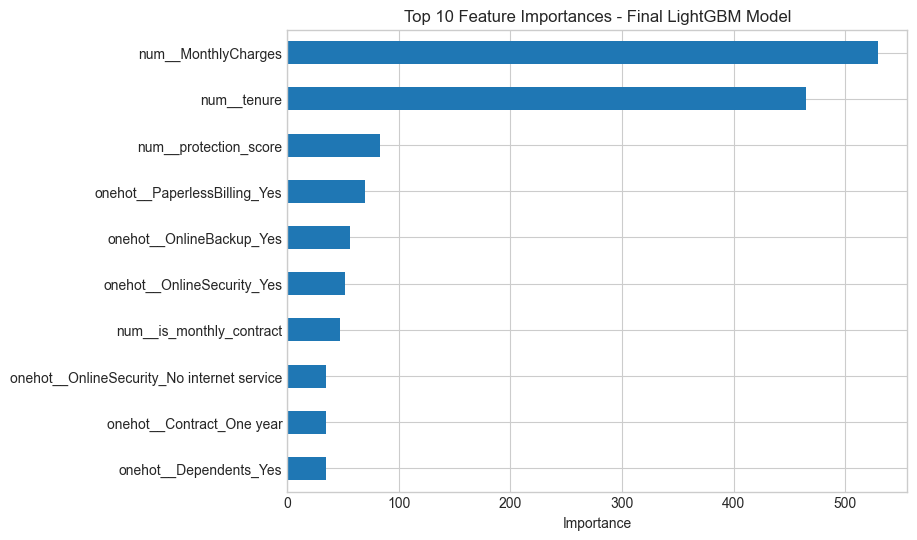

In [118]:
# Feature Importance
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()
importances = best_model.named_steps['model'].feature_importances_

fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
fi.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances - Final LightGBM Model')
plt.xlabel('Importance')
plt.show()

Feature importance membantu mengidentifikasi fitur mana yang paling berpengaruh dalam memprediksi churn.

In [119]:
print("Model LightGBM + Oversampling + Tuning")
print(f"ROC AUC (Test) : {roc_auc_tuned:.4f}")
print("\nClassification Report Tuned LGBM:\n")
print(report_tuned)

Model LightGBM + Oversampling + Tuning
ROC AUC (Test) : 0.8454

Classification Report Tuned LGBM:

              precision    recall  f1-score   support

           0       0.90      0.75      0.82       713
           1       0.53      0.78      0.63       258

    accuracy                           0.76       971
   macro avg       0.72      0.76      0.72       971
weighted avg       0.80      0.76      0.77       971



Evaluasi akhir menampilkan performa model churn pada data test, dengan fokus pada Recall dan ROC AUC.

In [120]:
# Model LightGBM + RandomOverSampler + Target Encoder
ros = RandomOverSampler(random_state=2025)

final_lgbm = lgb.LGBMClassifier(random_state=2025, num_leaves=31, max_bin=230, min_child_samples=20, n_estimators=150, learning_rate=0.1)
final_pipeline = ImbPipeline(steps=[('oversampling', ros), ('target_encoding', ce.TargetEncoder(cols=categorical_features)), ('model', final_lgbm)])

Model final mengintegrasikan Target Encoding untuk fitur kategorikal agar performa churn bisa meningkat.

In [121]:
# Cross-validation di train
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=2025)
cv_scores = cross_val_score(final_pipeline, x_train, y_train, cv=skfold, scoring='roc_auc', n_jobs=-1)

print("Final LightGBM + TargetEncoder + ROS (Train CV)")
print(f"Mean ROC AUC : {cv_scores.mean():.4f}")
print(f"Std  ROC AUC : {cv_scores.std():.4f}")

Final LightGBM + TargetEncoder + ROS (Train CV)
Mean ROC AUC : 0.8136
Std  ROC AUC : 0.0169


Cross-validation pada pipeline final digunakan untuk memastikan performa model stabil pada data churn.

In [122]:
# Fit final model di seluruh train
final_pipeline.fit(x_train, y_train)
y_proba_final = final_pipeline.predict_proba(x_test)[:, 1]
y_pred_final = (y_proba_final >= 0.5).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("ROC AUC  :", roc_auc_score(y_test, y_proba_final))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_final))

[LightGBM] [Info] Number of positive: 2852, number of negative: 2852
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000166 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 343
[LightGBM] [Info] Number of data points in the train set: 5704, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy : 0.7703398558187435
ROC AUC  : 0.8291991476129902

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.79      0.83       713
           1       0.55      0.72      0.63       258

    accuracy                           0.77       971
   macro avg       0.72      0.75      0.73       971
weighted avg       0.80      0.77      0.78       971



Evaluasi pada data uji memperlihatkan seberapa baik model mendeteksi pelanggan churn dan non-churn secara seimbang.

## Conclusion & Recommendation

In [123]:
print('Best Classification Report Tuned')
print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("ROC AUC  :", roc_auc_score(y_test, y_proba_final))
print(classification_report(y_test, y_pred_final))

Best Classification Report Tuned
Accuracy : 0.7703398558187435
ROC AUC  : 0.8291991476129902
              precision    recall  f1-score   support

           0       0.89      0.79      0.83       713
           1       0.55      0.72      0.63       258

    accuracy                           0.77       971
   macro avg       0.72      0.75      0.73       971
weighted avg       0.80      0.77      0.78       971



Bagian ini merangkum performa model pada data uji menggunakan metrik utama seperti Recall dan ROC AUC.

Berdasarkan hasil akhir classification report, model mampu mengenali sebagian besar pelanggan yang berpotensi churn sekaligus menjaga ketepatan pada pelanggan yang tetap berlangganan.

Dari sisi bisnis, prediksi churn yang lebih akurat dapat membantu tim retensi menargetkan pelanggan berisiko tinggi dengan lebih efektif, sehingga mengurangi kehilangan pendapatan berulang.

Model ini memberikan dasar untuk strategi retensi yang lebih tepat sasaran, misalnya penawaran promo khusus atau peningkatan layanan pada segmen dengan risiko churn tinggi.

### Recommendation

Hal-hal yang bisa dilakukan untuk mengembangkan project dan modelnya lebih baik lagi di masa depan:
- Menguji algoritma lain yang khusus menangani fitur kategorikal secara native seperti CatBoost.
- Menganalisis pelanggan yang salah prediksi (false negative churn) untuk memahami pola churn yang belum tertangkap fitur saat ini.
- Menambahkan fitur perilaku lain (misalnya pola penggunaan layanan atau histori komplain) agar model semakin kaya informasi.